<div style="text-align:center; padding: 24px 16px; border: 2px solid #D9E4F2; border-radius: 16px; background: linear-gradient(90deg, #F8FBFF 0%, #EEF5FF 100%);">

<h1 style="color:#000000; margin-bottom:10px;">Riyadh Airport Flight Analysis</h1>

<h3 style="color:#000000; margin-top:0;">
Exploratory Data Analysis and Forecasting Notebook
</h3>

<br>

<p style="color:#000000; font-weight:600;">
Prepared in a business-oriented analytical format
</p>

<p style="color:#000000; font-size:16px; line-height:1.6;">
This notebook presents an analytical study of flight departures from 
<strong>King Khalid International Airport in Riyadh</strong> using a recent operational dataset.
It combines <strong>data preprocessing, exploratory data analysis, business-oriented insights,
and forecasting techniques</strong> to better understand traffic patterns, operational behavior,
and future flight activity.
</p>

<br>

<p style="color:#000000; font-size:15px;">
<strong>Prepared by:</strong> Faisal Al-Sulami
</p>

</div>

---

# Introduction

This notebook analyzes flight departure data from **King Khalid International Airport in Riyadh** to understand operational patterns, destination demand, airline activity, and airport usage.

The analysis follows a complete data workflow including **data inspection, preprocessing, exploratory data analysis (EDA), and forecasting**. The goal is to transform raw operational data into meaningful insights that help explain airport activity and support better decision-making.

The dataset used in this analysis is **recent and operationally relevant**, with the latest update in **October 2025**, making it useful for understanding current aviation trends in Riyadh.

### Limitation
Although the dataset contains a **large number of records**, it covers only **approximately seven months of activity**, which means it does not represent a full yearly cycle. Therefore, seasonal aviation patterns across the entire year may not be fully captured.

---

# Dataset Column Definitions

The dataset contains several fields describing different aspects of each flight. Below is a brief explanation of the main columns used in the analysis.

| Column | Description |
|------|------|
| **flight_number** | Unique identifier assigned to each flight. |
| **aircraft.model** | Aircraft type used to operate the flight. |
| **aircraft.reg** | Aircraft registration number. |
| **aircraft.modeS** | Unique Mode-S identifier used for aircraft surveillance. |
| **airline.name** | Name of the airline operating the flight. |
| **airline.iata** | IATA code of the airline. |
| **airline.icao** | ICAO code of the airline. |
| **status** | Operational status of the flight (scheduled, active, cancelled, etc.). |
| **flight_type** | Indicates whether the flight is **Domestic** or **International**. |
| **codeshareStatus** | Shows whether the flight is part of a codeshare agreement. |
| **isCargo** | Indicates whether the flight is a cargo flight. |
| **callSign** | Communication call sign used by the aircraft. |
| **origin_airport_name** | Name of the airport where the flight originated. |
| **origin_airport_iata** | IATA code of the origin airport. |
| **origin_airport_icao** | ICAO code of the origin airport. |
| **destination_airport_name** | Name of the destination airport. |
| **destination_airport_iata** | IATA code of the destination airport. |
| **destination_airport_icao** | ICAO code of the destination airport. |
| **movement.terminal** | Airport terminal used for the flight at Riyadh Airport. |
| **movement.quality** | Indicator describing the reliability of the movement data. |
| **movement.airport.timeZone** | Time zone associated with the airport. |
| **movement.scheduledTime.utc** | Scheduled flight time in UTC. |
| **movement.scheduledTime.local** | Scheduled flight time in Riyadh local time. |

---
# Notebook Structure

The notebook is organized into several sections that guide the analysis from raw data exploration to final insights and forecasting.

1. **Data Loading and Initial Inspection**  
   Loading the dataset and performing an initial exploration to understand the structure, size, and basic characteristics of the data.

2. **Data Preprocessing**  
   Cleaning and preparing the dataset by handling missing values, formatting time-related variables, and creating the fields required for analysis.

3. **Business-Oriented Visual Analysis**  
   Conducting exploratory data analysis through visualizations to identify important patterns in destinations, airlines, terminals, and flight activity over time.

4. **Forecasting Analysis**  
   Applying time-series forecasting techniques to estimate future flight activity based on historical patterns.

5. **Reflection and Limitations**  
   Discussing the limitations of the dataset and forecasting models, and reflecting on factors that may affect prediction accuracy.

6. **Conclusion**  
   Summarizing the main findings of the analysis and highlighting the key observations derived from the data.

---
## 1. Data Loading and Initial Inspection
The following cells import the required libraries, load the dataset, and perform a first-pass inspection of the data structure and quality.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style for all plots
sns.set_theme(style="whitegrid", context="talk")

# Load the dataset
file_path = r"C:\Users\faisa\Downloads\flights_RUH.csv"
df = pd.read_csv(file_path)

# Display the first 10 rows
df.head(10)

,flight_number,aircraft.model,aircraft.reg,aircraft.modeS,airline.name,airline.iata,airline.icao,status,flight_type,codeshareStatus,...,origin_airport_icao,origin_airport_iata,movement.terminal,movement.quality,destination_airport_icao,destination_airport_iata,destination_airport_name,movement.airport.timeZone,movement.scheduledTime.utc,movement.scheduledTime.local
0,PF 769,Airbus A320,NaN,NaN,Air Sial,PF,NaN,Unknown,departure,Unknown,...,OERK,RUH,2.0,['Basic'],OPIS,ISB,Islamabad,Asia/Karachi,2025-03-14 21:01Z,2025-03-15 00:01+03:00
1,XY 333,Airbus A320 NEO,HZ-NS35,710DB9,flynas,XY,KNE,Unknown,departure,IsOperator,...,OERK,RUH,1.0,['Basic'],VILK,LKO,Lucknow,Asia/Kolkata,2025-03-14 21:05Z,2025-03-15 00:05+03:00
2,QP 568,Boeing 737,NaN,NaN,Starlight Airline,QP,SLT,Unknown,departure,Unknown,...,OERK,RUH,3.0,['Basic'],VABB,BOM,Mumbai,Asia/Kolkata,2025-03-14 21:05Z,2025-03-15 00:05+03:00
3,F3 161,Airbus A320,NaN,NaN,flyadeal,F3,FAD,Unknown,departure,Unknown,...,OERK,RUH,5.0,['Basic'],OEJN,JED,Jeddah,Asia/Riyadh,2025-03-14 21:10Z,2025-03-15 00:10+03:00
4,KL 423,Airbus A330-300,NaN,NaN,KLM,KL,KLM,Unknown,departure,Unknown,...,OERK,RUH,1.0,['Basic'],OEDF,DMM,Ad Dammam,Asia/Riyadh,2025-03-14 21:15Z,2025-03-15 00:15+03:00
5,SV 742,Boeing 777,HZ-AK30,710108,Saudi Arabian,SV,SVA,Unknown,departure,IsOperator,...,OERK,RUH,4.0,['Basic'],VABB,BOM,Mumbai,Asia/Kolkata,2025-03-14 21:25Z,2025-03-15 00:25+03:00
6,CZ 5008,Airbus A330,B-8366,78114B,China Southern,CZ,CSN,Departed,departure,IsOperator,...,OERK,RUH,1.0,['Basic'],ZGSZ,SZX,Shenzhen,Asia/Shanghai,2025-03-14 21:30Z,2025-03-15 00:30+03:00
7,SV 1845,Airbus A320,NaN,NaN,Saudi Arabian,SV,SVA,Unknown,departure,Unknown,...,OERK,RUH,5.0,['Basic'],OENG,EAM,Neyran,Asia/Riyadh,2025-03-14 21:30Z,2025-03-15 00:30+03:00
8,SV 1011,Airbus A320,NaN,NaN,Saudi Arabian,SV,SVA,Unknown,departure,Unknown,...,OERK,RUH,5.0,['Basic'],OEJN,JED,Jeddah,Asia/Riyadh,2025-03-14 21:30Z,2025-03-15 00:30+03:00
9,XY 61,Airbus A320 NEO,NaN,NaN,flynas,XY,KNE,Unknown,departure,Unknown,...,OERK,RUH,5.0,['Basic'],OEJN,JED,Jeddah,Asia/Riyadh,2025-03-14 21:35Z,2025-03-15 00:35+03:00


In [2]:
# Calculate the percentage of missing values in each column
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Display missing value percentages sorted from highest to lowest
missing_percentage.sort_values(ascending=False)

aircraft.reg                    76.365226
callSign                        70.557962
aircraft.modeS                  70.431419
destination_airport_iata         2.678269
destination_airport_icao         2.678269
movement.airport.timeZone        2.678269
movement.terminal                0.554439
airline.icao                     0.367235
aircraft.model                   0.121324
airline.iata                     0.009132
flight_number                    0.000000
airline.name                     0.000000
status                           0.000000
codeshareStatus                  0.000000
flight_type                      0.000000
origin_airport_iata              0.000000
origin_airport_icao              0.000000
origin_airport_name              0.000000
isCargo                          0.000000
movement.quality                 0.000000
destination_airport_name         0.000000
movement.scheduledTime.utc       0.000000
movement.scheduledTime.local     0.000000
dtype: float64

In [3]:
# Display the percentage distribution of flight status values
df["status"].value_counts(normalize=True).mul(100).round(2)

status
Unknown              83.90
Expected              8.52
Departed              7.51
Canceled              0.05
CanceledUncertain     0.02
Name: proportion, dtype: float64

In [4]:
# Display dataset structure, data types, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153308 entries, 0 to 153307
Data columns (total 23 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   flight_number                 153308 non-null  object 
 1   aircraft.model                153122 non-null  object 
 2   aircraft.reg                  36234 non-null   object 
 3   aircraft.modeS                45331 non-null   object 
 4   airline.name                  153308 non-null  object 
 5   airline.iata                  153294 non-null  object 
 6   airline.icao                  152745 non-null  object 
 7   status                        153308 non-null  object 
 8   flight_type                   153308 non-null  object 
 9   codeshareStatus               153308 non-null  object 
 10  isCargo                       153308 non-null  bool   
 11  callSign                      45137 non-null   object 
 12  origin_airport_name           153308 non-nul

In [5]:
df.describe()

,movement.terminal
count,152458.000000
mean,3.869144
std,1.465256
min,1.000000
25%,3.000000
50%,5.000000
75%,5.000000
max,5.000000


In [6]:
# Calculate the missing ratio for each column
missing = df.isnull().mean()

# Identify columns with more than 50% missing values
cols_over_50 = missing[missing > 0.5].index.tolist()

# Identify text-based columns
text_cols = df.select_dtypes(include="object").columns.tolist()

# Identify date/time-like columns based on column names
date_like_cols = [col for col in df.columns if "time" in col.lower()]

# Print a concise data quality summary
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print(f"Duplicate rows: {df.duplicated().sum()}")

print("\nColumns with missing values:")
print((df.isnull().sum() > 0).sum())

print("\nColumns with >50% missing:")
print(len(cols_over_50))
print(cols_over_50)

print("\nText columns:")
print(len(text_cols))
print(text_cols)

print("\nDate/time-like columns:")
print(len(date_like_cols))
print(date_like_cols)

Number of rows: 153308
Number of columns: 23
Duplicate rows: 0

Columns with missing values:
10

Columns with >50% missing:
3
['aircraft.reg', 'aircraft.modeS', 'callSign']

Text columns:
21
['flight_number', 'aircraft.model', 'aircraft.reg', 'aircraft.modeS', 'airline.name', 'airline.iata', 'airline.icao', 'status', 'flight_type', 'codeshareStatus', 'callSign', 'origin_airport_name', 'origin_airport_icao', 'origin_airport_iata', 'movement.quality', 'destination_airport_icao', 'destination_airport_iata', 'destination_airport_name', 'movement.airport.timeZone', 'movement.scheduledTime.utc', 'movement.scheduledTime.local']

Date/time-like columns:
3
['movement.airport.timeZone', 'movement.scheduledTime.utc', 'movement.scheduledTime.local']


---
## 2. Data Preprocessing
This section prepares the dataset for analysis by converting date fields, deriving time-based features, handling structure-related issues, and creating route categories used later in the visual analysis.


In [7]:
# =========================
# Data Preprocessing
# =========================

# Convert time columns to datetime format
df["movement.scheduledTime.local"] = pd.to_datetime(
    df["movement.scheduledTime.local"], errors="coerce"
)

df["movement.scheduledTime.utc"] = pd.to_datetime(
    df["movement.scheduledTime.utc"], errors="coerce"
)

# Remove columns that are either highly incomplete or not useful for this analysis
df = df.drop(columns=[
    "aircraft.reg",
    "aircraft.modeS",
    "callSign",
    "movement.airport.timeZone",
    "status",
    "aircraft.model",
    "codeshareStatus",
    "isCargo"
])
       

# Fill missing values in important categorical columns
df["destination_airport_iata"] = df["destination_airport_iata"].fillna("Unknown")
df["destination_airport_icao"] = df["destination_airport_icao"].fillna("Unknown")
df["airline.iata"] = df["airline.iata"].fillna("Unknown")
df["airline.icao"] = df["airline.icao"].fillna("Unknown")

# Drop rows with missing terminal values because the ratio is very small
df = df.dropna(subset=["movement.terminal"])

# Create useful time-based features for analysis
df["date"] = df["movement.scheduledTime.local"].dt.floor("D")
df["year"] = df["movement.scheduledTime.local"].dt.year
df["month"] = df["movement.scheduledTime.local"].dt.month
df["month_name"] = df["movement.scheduledTime.local"].dt.month_name()
df["day"] = df["movement.scheduledTime.local"].dt.day
df["day_of_week"] = df["movement.scheduledTime.local"].dt.day_name()
df["hour"] = df["movement.scheduledTime.local"].dt.hour

# Sort the dataset chronologically
df = df.sort_values("movement.scheduledTime.local")

# Reset index after preprocessing
df = df.reset_index(drop=True)

# Display a quick check after preprocessing
print("Shape after preprocessing:", df.shape)

print("\nRemaining Missing Values:")
print(df.isnull().sum())

df.head()

Shape after preprocessing: (152458, 22)

Remaining Missing Values:
flight_number                   0
airline.name                    0
airline.iata                    0
airline.icao                    0
flight_type                     0
origin_airport_name             0
origin_airport_icao             0
origin_airport_iata             0
movement.terminal               0
movement.quality                0
destination_airport_icao        0
destination_airport_iata        0
destination_airport_name        0
movement.scheduledTime.utc      0
movement.scheduledTime.local    0
date                            0
year                            0
month                           0
month_name                      0
day                             0
day_of_week                     0
hour                            0
dtype: int64


,flight_number,airline.name,airline.iata,airline.icao,flight_type,origin_airport_name,origin_airport_icao,origin_airport_iata,movement.terminal,movement.quality,...,destination_airport_name,movement.scheduledTime.utc,movement.scheduledTime.local,date,year,month,month_name,day,day_of_week,hour
0,PF 769,Air Sial,PF,Unknown,departure,Riyadh,OERK,RUH,2.0,['Basic'],...,Islamabad,2025-03-14 21:01:00+00:00,2025-03-15 00:01:00+03:00,2025-03-15 00:00:00+03:00,2025,3,March,15,Saturday,0
1,SV 1734,Saudi Arabian,SV,SVA,arrival,Riyadh,OERK,RUH,5.0,['Basic'],...,Bisha,2025-03-14 21:05:00+00:00,2025-03-15 00:05:00+03:00,2025-03-15 00:00:00+03:00,2025,3,March,15,Saturday,0
2,SV 1528,Saudi Arabian,SV,SVA,arrival,Riyadh,OERK,RUH,5.0,['Basic'],...,Tabuk,2025-03-14 21:05:00+00:00,2025-03-15 00:05:00+03:00,2025-03-15 00:00:00+03:00,2025,3,March,15,Saturday,0
3,QP 568,Starlight Airline,QP,SLT,departure,Riyadh,OERK,RUH,3.0,['Basic'],...,Mumbai,2025-03-14 21:05:00+00:00,2025-03-15 00:05:00+03:00,2025-03-15 00:00:00+03:00,2025,3,March,15,Saturday,0
4,XY 333,flynas,XY,KNE,departure,Riyadh,OERK,RUH,1.0,['Basic'],...,Lucknow,2025-03-14 21:05:00+00:00,2025-03-15 00:05:00+03:00,2025-03-15 00:00:00+03:00,2025,3,March,15,Saturday,0


In [8]:
# Display all unique destination airport names
print("Unique destination airport names:\n")
print(sorted(df["destination_airport_name"].dropna().unique()))

Unique destination airport names:

['Abha', 'Abu Dhabi Island and Internal Islands City', 'Ad Dammam', 'Addis Ababa', 'Al Qaysumah', 'Al Ula', 'Al-Bakha', 'Al-Jawf', 'Al-Ula', 'Alexandria', 'Amman', 'Amsterdam', 'Antalya', 'Arar', 'Assiut', 'Athens', 'Baku', 'Bangkok', 'Barcelona', 'Batumi', 'Beijing', 'Beirut', 'Bisha', 'Bodrum', 'Burayda', 'Cairo', 'Calicut', 'Casablanca', 'Colombo', 'Dalian', 'Damascus', 'Dammam', 'Dawadmi', 'Deli', 'Dhaka', 'Doha', 'Dubai', 'Dzhuf', 'El Alamein', 'Entebbe', 'Frankfurt-am-Main', 'Geneva', 'Gerayat', 'Guangzhou', 'Hangzhou', 'Hong Kong', 'Hurghada', 'Hyderabad', 'Islamabad', 'Istanbul', 'Jakarta', 'Jazan', 'Jebel Ali', 'Jeddah', 'Kabul', 'Kampala', 'Kannur International Airport', 'Karachi', 'Kathmandu', 'Kaysuma', 'Khail', 'Kochi', 'Kozhikode', 'Kraków', 'Kuala Lumpur', 'Kuwait City', 'Lahore', 'Larnarca', 'London', 'Lucknow', 'Malé', 'Manama', 'Manila', 'Medina', 'Milan', 'Moscow', 'Multan', 'Mumbai', 'Munich', 'Muscat', 'Málaga', 'Nairobi', 'Neom B

In [9]:
# Define Saudi domestic destinations
saudi_cities = {
    "Abha", "Ad Dammam", "Al Qaysumah", "Al Ula", "Al-Ula", "Al-Bakha",
    "Al-Jawf", "Arar", "Bisha", "Burayda", "Dammam", "Dawadmi", "Gerayat",
    "Jazan", "Jeddah", "Khail", "Kaysuma", "Medina", "Neyran",
    "Neom Bay Airport", "Rafha", "Sharura", "Tabuk", "Taif",
    "Turayf", "Vadi-ed-Davasir", "Yanbu"
}

# Classify each destination as Domestic or International
df["route_type"] = df["destination_airport_name"].apply(
    lambda x: "Domestic" if x in saudi_cities else "International"
)

# Check route type distribution
df["route_type"].value_counts()

route_type
Domestic         80895
International    71563
Name: count, dtype: int64

---
## 3. Business-Oriented Visual Analysis
The following visualizations are not only descriptive; each one is followed by a focused **Insight** and **Business Value** statement to show how the findings can support stakeholders and decision-makers.


### Domestic vs International Flights
**Why this chart matters:** To understand the overall balance between domestic and international traffic at Riyadh Airport.

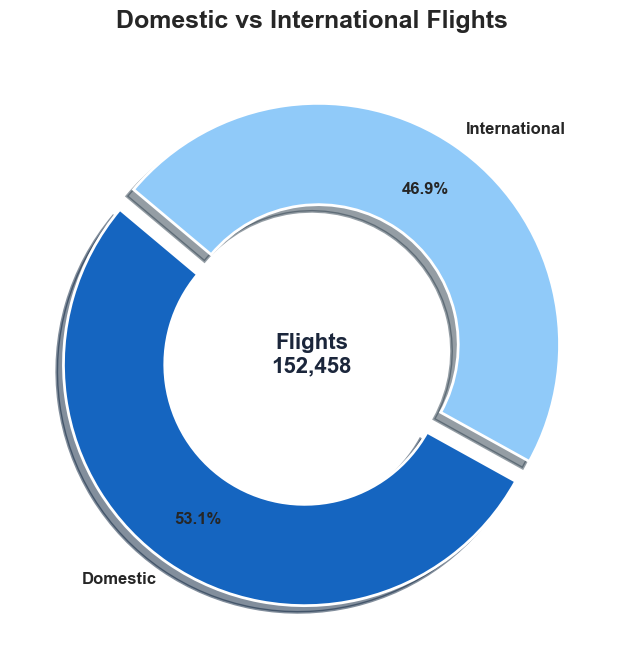

In [62]:

route_counts = df["route_type"].value_counts()

colors = ["#1565C0", "#90CAF9"]

fig, ax = plt.subplots(figsize=(7, 7), facecolor="white")

wedges, texts, autotexts = ax.pie(
    route_counts,
    labels=route_counts.index,
    autopct=lambda p: f"{p:.1f}%",
    startangle=140,
    colors=colors,
    explode=[0.05] * len(route_counts),
    shadow=True,
    wedgeprops=dict(width=0.42, edgecolor="white", linewidth=2),
    pctdistance=0.78,
    labeldistance=1.08,
    textprops=dict(fontsize=12, fontweight="bold")
)

# Add values inside center
ax.text(
    0, 0,
    f"Flights\n{route_counts.sum():,}",
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold",
    color="#1b263b"
)

plt.title(
    "Domestic vs International Flights",
    fontsize=18,
    fontweight="bold",
    pad=18
)

plt.tight_layout()
plt.show()

> **Insight:**  
> Flight traffic at Riyadh Airport is relatively balanced between domestic and international operations. Domestic flights account for a slightly larger share of total traffic (about 53%), while international flights represent nearly 47%, indicating strong connectivity both within Saudi Arabia and with global destinations.
>
> **Business Value:**  
> This balanced distribution highlights Riyadh Airport’s dual role as both a national transportation hub and an international gateway. Maintaining strong domestic connectivity while expanding international routes can support tourism growth, strengthen global connectivity, and increase airport revenue opportunities.

### Top Domestic Destinations from Riyadh
**Why this chart matters:** To identify the strongest domestic routes and where operational demand is most concentrated.

C:\Users\faisa\AppData\Local\Temp\ipykernel_17012\2777910734.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


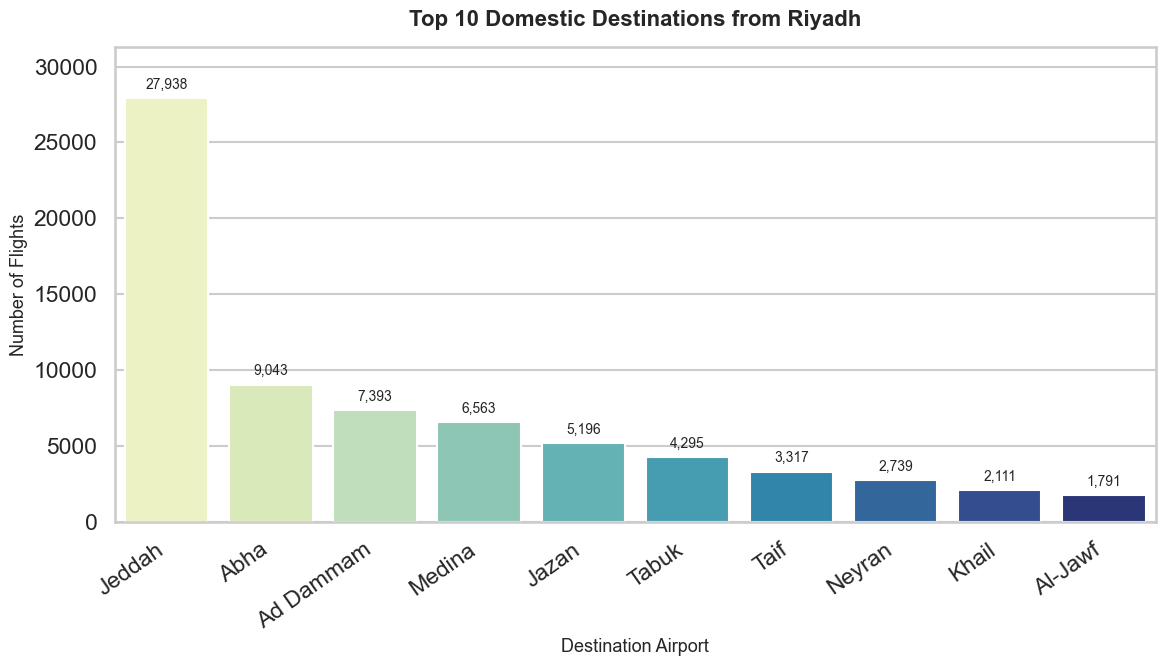

In [11]:
# Get the top 10 domestic destinations by number of flights
top_domestic = (
    df[df["route_type"] == "Domestic"]["destination_airport_name"]
    .value_counts()
    .head(10)
)

# Create the plot
plt.figure(figsize=(12, 7))
ax = sns.barplot(
    x=top_domestic.index,
    y=top_domestic.values,
    palette="YlGnBu"
)

# Add value labels above bars
for i, value in enumerate(top_domestic.values):
    ax.text(
        i,
        value + (top_domestic.max() * 0.015),
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Add headroom above the tallest bar
ax.set_ylim(0, top_domestic.max() * 1.12)

plt.title("Top 10 Domestic Destinations from Riyadh", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Destination Airport", fontsize=13)
plt.ylabel("Number of Flights", fontsize=13)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

> **Insight:** The Riyadh–Jeddah route dominates domestic traffic, indicating consistently high travel demand between the two cities.
>
> **Business Value:** Increasing flight frequency and distributing additional flights across different times of the day can better accommodate demand while reducing congestion.

### Top International Destinations from Riyadh
**Why this chart matters:** To highlight the international markets that attract the highest outbound demand from Riyadh.

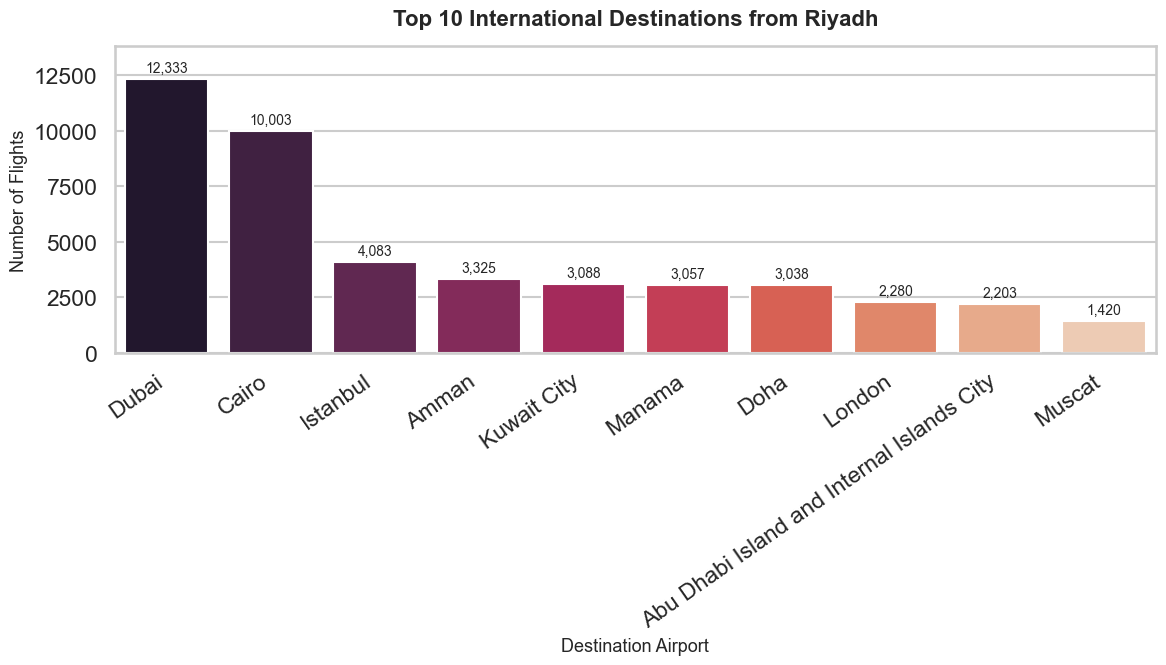

In [40]:
# Get the top 10 international destinations by number of flights
top_international = (
    df[df["route_type"] == "International"]["destination_airport_name"]
    .value_counts()
    .head(10)
)

# Create the plot
plt.figure(figsize=(12, 7))
ax = sns.barplot(
    x=top_international.index,
    y=top_international.values,
    palette="rocket"
)

# Add value labels above bars
for i, value in enumerate(top_international.values):
    ax.text(
        i,
        value + (top_international.max() * 0.015),
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Add headroom above the tallest bar
ax.set_ylim(0, top_international.max() * 1.12)

plt.title("Top 10 International Destinations from Riyadh", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Destination Airport", fontsize=13)
plt.ylabel("Number of Flights", fontsize=13)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

> **Insight:** Most international flights from Riyadh are concentrated in nearby regional cities such as Dubai, Cairo, and Istanbul.
>
> **Business Value:** Airlines can prioritize high-demand regional routes because they combine strong passenger demand with relatively efficient operating economics.

### Top Airlines Operating at Riyadh Airport
**Why this chart matters:** To show which airlines dominate airport activity and where market concentration exists.

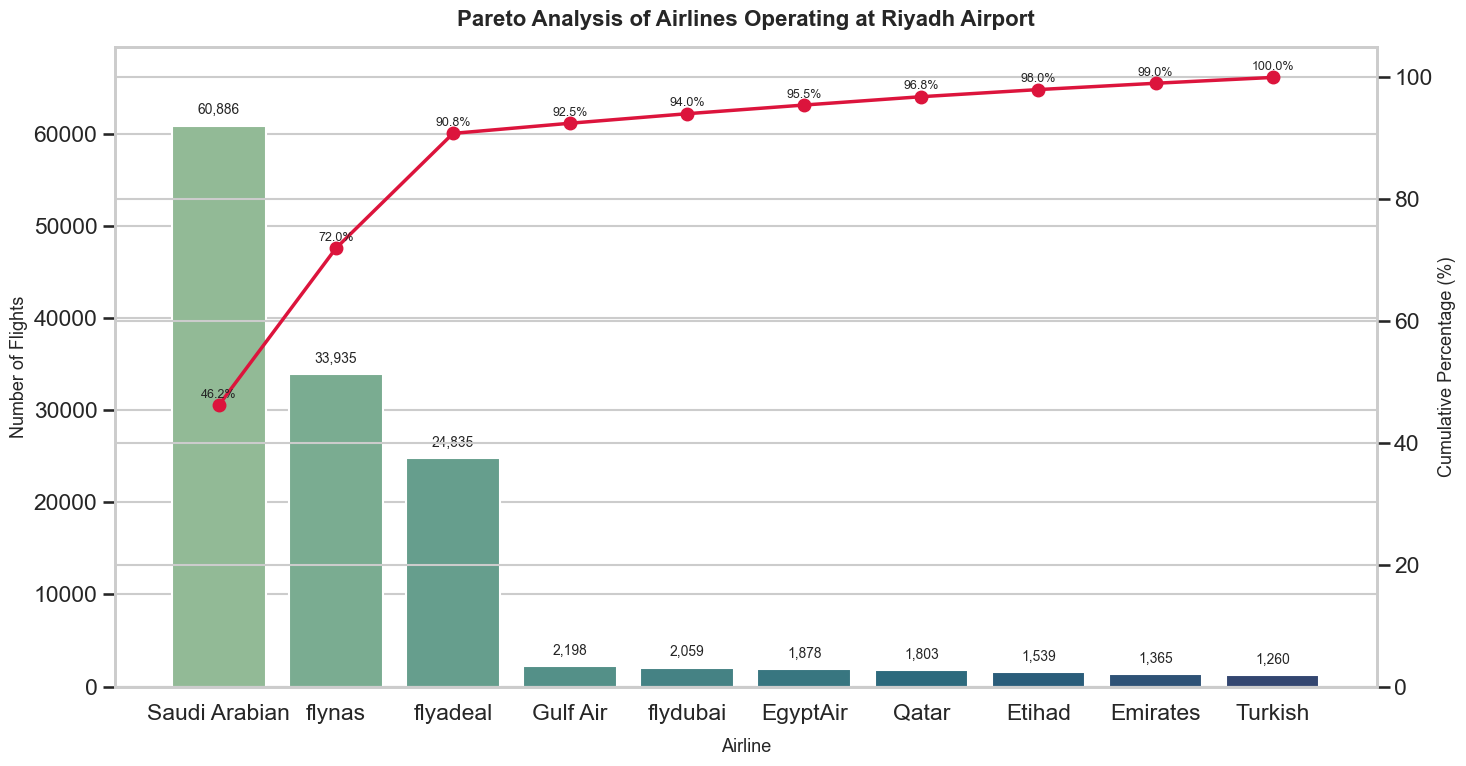

In [61]:
# Get the top 10 airlines by number of flights
top_airlines = df["airline.name"].value_counts().head(10)

# Shorten long airline names for better readability
top_airlines.index = [
    "Saudi Arabian", "flynas", "flyadeal", "Gulf Air", "flydubai",
    "EgyptAir", "Qatar", "Etihad", "Emirates", "Turkish"
]

# Calculate cumulative percentage
cum_percent = top_airlines.cumsum() / top_airlines.sum() * 100

# Create the figure
fig, ax = plt.subplots(figsize=(15, 8))

# Create the bar chart (frequency)
sns.barplot(
    x=top_airlines.index,
    y=top_airlines.values,
    palette="crest",
    ax=ax
)

# Add value labels above bars
for i, value in enumerate(top_airlines.values):
    ax.text(
        i,
        value + (top_airlines.max() * 0.015),
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Add headroom above the tallest bar
ax.set_ylim(0, top_airlines.max() * 1.14)

# Create second axis for cumulative percentage
ax2 = ax.twinx()

# Plot cumulative percentage line
ax2.plot(
    range(len(top_airlines.index)),
    cum_percent,
    color="crimson",
    marker="o",
    linewidth=2.5
)

# Add percentage labels on the line points
for i, value in enumerate(cum_percent):
    ax2.text(
        i,
        value + 1.2,
        f"{value:.1f}%",
        ha="center",
        fontsize=9
    )

# Set cumulative percentage axis limits
ax2.set_ylim(0, 105)
ax2.set_ylabel("Cumulative Percentage (%)", fontsize=13)

# Add title and labels
ax.set_title(
    "Pareto Analysis of Airlines Operating at Riyadh Airport",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Airline", fontsize=13, labelpad=10)
ax.set_ylabel("Number of Flights", fontsize=13)

# Rotate airline names for readability
plt.xticks(rotation=20, ha="center", fontsize=11)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

> **Insight:**  
> The Pareto chart shows a strong concentration in airline operations at Riyadh Airport. The top three airlines — Saudi Arabian Airlines, flynas, and flyadeal — account for nearly 90% of total flights, while the remaining airlines contribute only a small portion of overall traffic.
>
> **Business Value:**  
> Understanding this market concentration helps airport management evaluate airline dependency and strategic partnerships. Diversifying airline participation could increase international connectivity, reduce reliance on a few carriers, and enhance the airport’s global network competitiveness.

### Top Destination Airports from Riyadh
**Why this chart matters:** To identify the most important airports served from Riyadh across all route types.

C:\Users\faisa\AppData\Local\Temp\ipykernel_17012\1403890503.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


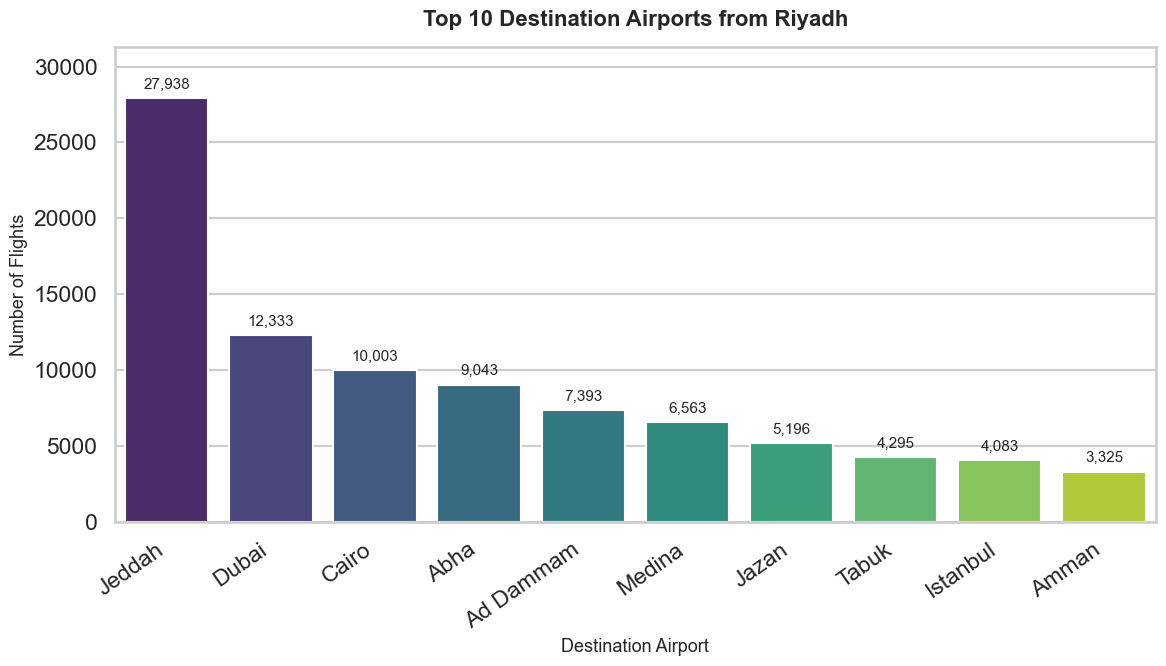

In [14]:
# Get the top 10 destination airports by flight count
top_dest = df["destination_airport_name"].value_counts().head(10)

# Create the plot
plt.figure(figsize=(12, 7))
ax = sns.barplot(
    x=top_dest.index,
    y=top_dest.values,
    palette="viridis"
)

# Add value labels above bars
for i, value in enumerate(top_dest.values):
    ax.text(
        i,
        value + (top_dest.max() * 0.015),
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=11
    )

# Add headroom above the tallest bar
ax.set_ylim(0, top_dest.max() * 1.12)

plt.title("Top 10 Destination Airports from Riyadh", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Destination Airport", fontsize=13)
plt.ylabel("Number of Flights", fontsize=13)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

> **Insight:** The most popular destinations from Riyadh are a mix of major Saudi cities and nearby regional airports.
>
> **Business Value:** This pattern confirms Riyadh’s role as a regional connectivity center and supports investment in strong short- and medium-haul route networks.

### Flights Distribution by Hour
**Why this chart matters:** To detect operational peak hours and periods of concentrated airport activity.

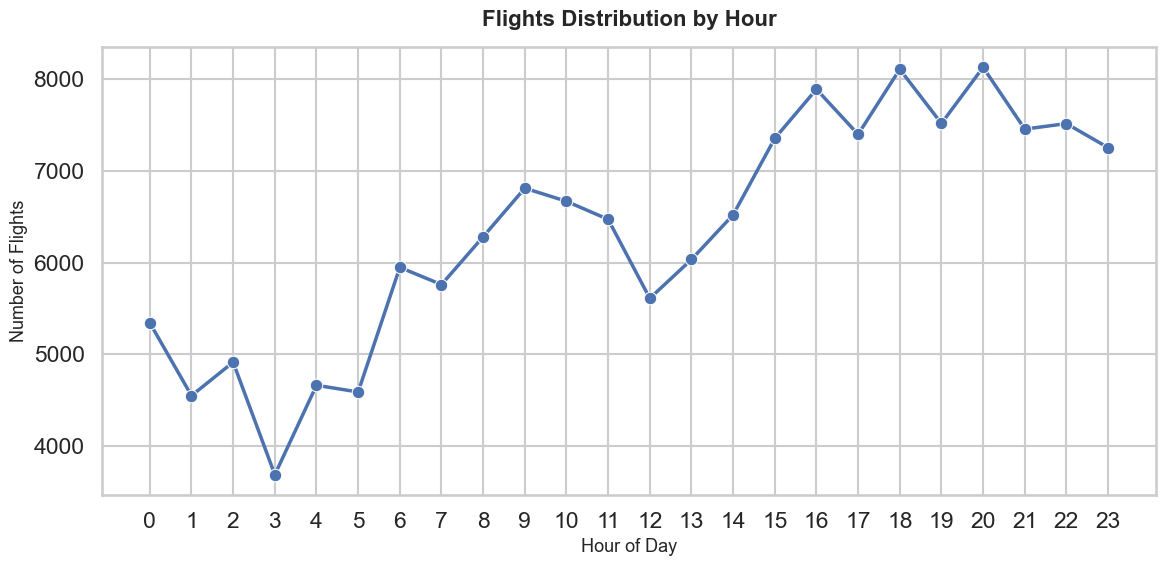

In [15]:
# Count flights by hour and ensure that all 24 hours are displayed
flights_hour = df["hour"].value_counts().sort_index().reindex(range(24), fill_value=0)

# Create the plot
plt.figure(figsize=(12, 6))
sns.lineplot(
    x=flights_hour.index,
    y=flights_hour.values,
    marker="o",
    linewidth=2.5
)

plt.title("Flights Distribution by Hour", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Hour of Day", fontsize=13)
plt.ylabel("Number of Flights", fontsize=13)
plt.xticks(range(24))
plt.tight_layout()
plt.show()

> **Insight:** Flight activity peaks during the evening hours, making this the busiest operational period of the day.
>
> **Business Value:** Allocating more staff, gates, and ground support during evening peaks can reduce congestion and improve passenger flow.

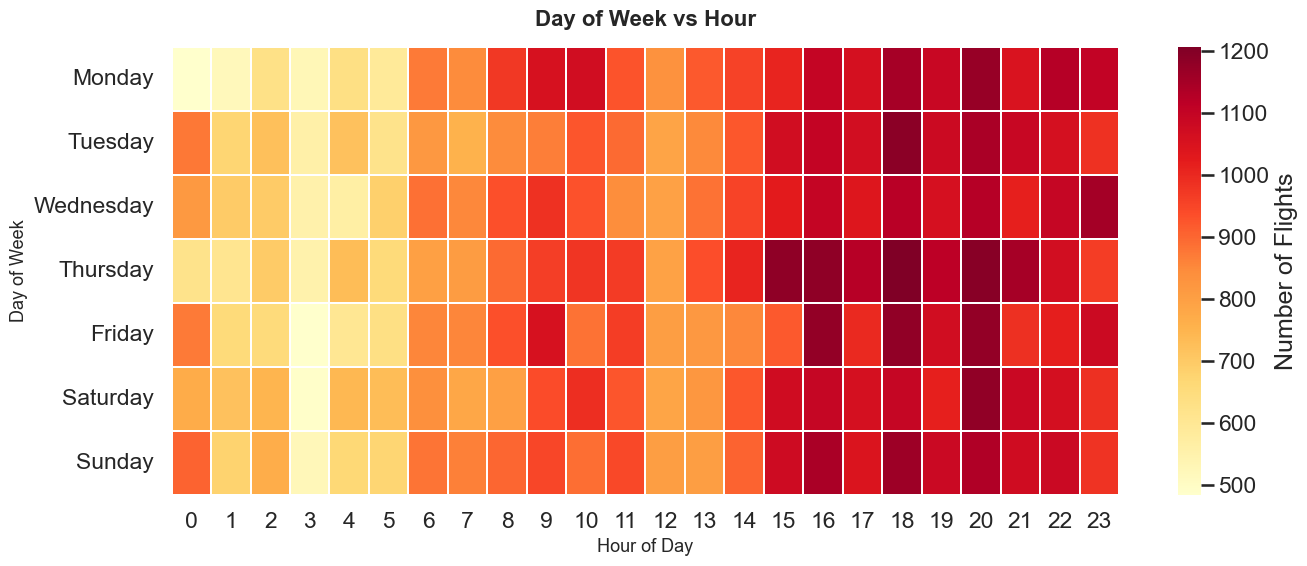

In [43]:
# Create pivot table for heatmap (day_of_week × hour)
heatmap_data = (
    df.groupby(["day_of_week", "hour"])
    .size()
    .reset_index(name="flights")
    .pivot(index="day_of_week", columns="hour", values="flights")
)

# Ensure hours from 0 to 23 exist
heatmap_data = heatmap_data.reindex(columns=range(24), fill_value=0)

# Order days of week correctly
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

heatmap_data = heatmap_data.reindex(day_order)

# Create the heatmap
plt.figure(figsize=(14, 6))

sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "Number of Flights"}
)

plt.title("Day of Week vs Hour", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Hour of Day", fontsize=13)
plt.ylabel("Day of Week", fontsize=13)

plt.tight_layout()
plt.show()

> **Insight:**  
> Flight activity varies across both days of the week and hours of the day. The heatmap shows that flight operations are generally lower during the early morning hours, then increase gradually throughout the day, reaching their highest intensity during the late afternoon and evening periods.
>
> **Business Value:**  
> Understanding these temporal traffic patterns helps airport management optimize resource allocation. By increasing staffing levels, gate availability, and ground operations during high-traffic hours, the airport can reduce delays, improve operational efficiency, and enhance passenger experience.

### Flights by Terminal
**Why this chart matters:** To assess how traffic is distributed across airport terminals and where pressure is highest.

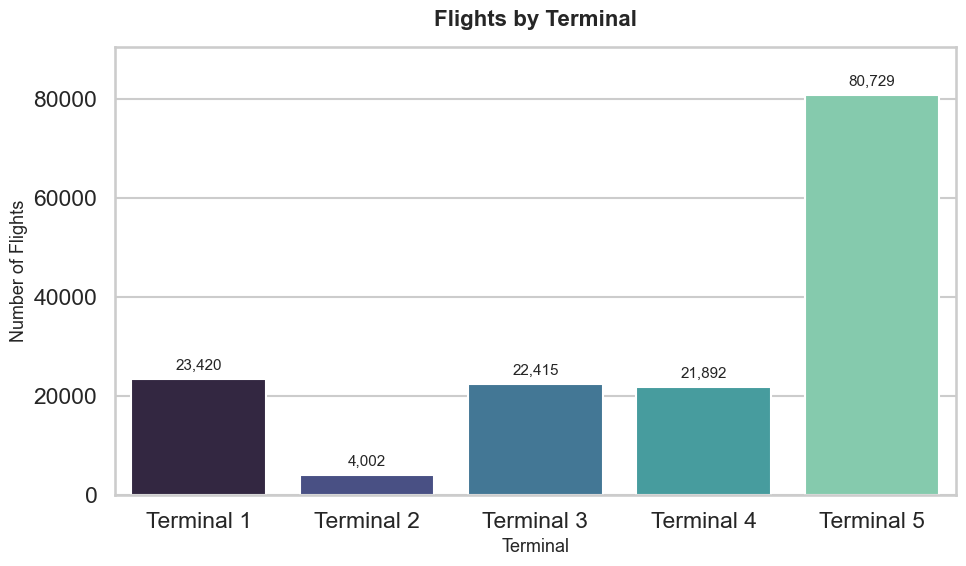

In [46]:
# Count flights by terminal
terminal_counts = df["movement.terminal"].value_counts().sort_index()

# Create readable terminal labels
terminal_labels = [f"Terminal {int(t)}" for t in terminal_counts.index]

# Create the plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=terminal_labels,
    y=terminal_counts.values,
    palette="mako"
)

# Add value labels above bars
for i, value in enumerate(terminal_counts.values):
    ax.text(
        i,
        value + (terminal_counts.max() * 0.015),
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=11
    )

# Add headroom above the tallest bar
ax.set_ylim(0, terminal_counts.max() * 1.12)

plt.title("Flights by Terminal", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Terminal", fontsize=13)
plt.ylabel("Number of Flights", fontsize=13)
plt.tight_layout()
plt.show()

> **Insight:**  
> Terminal 5 handled the largest share of flights in this dataset because it was primarily dedicated to domestic flights.  
> This concentration of traffic suggests that Terminal 5 experienced significantly higher operational pressure compared to other terminals.
>
> **Business Value:**  
> Insights like this can support data-driven operational decisions. In fact, a major terminal reallocation took place at Riyadh Airport on **25 February 2026**, where domestic flights were redistributed to **Terminals 3 and 4**.  
> Such decisions help reduce congestion, improve passenger flow, and balance airport operations more effectively.

### Flights by Day of Week
**Why this chart matters:** To evaluate whether flight demand changes across weekdays and weekends.

C:\Users\faisa\AppData\Local\Temp\ipykernel_17012\3292820562.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


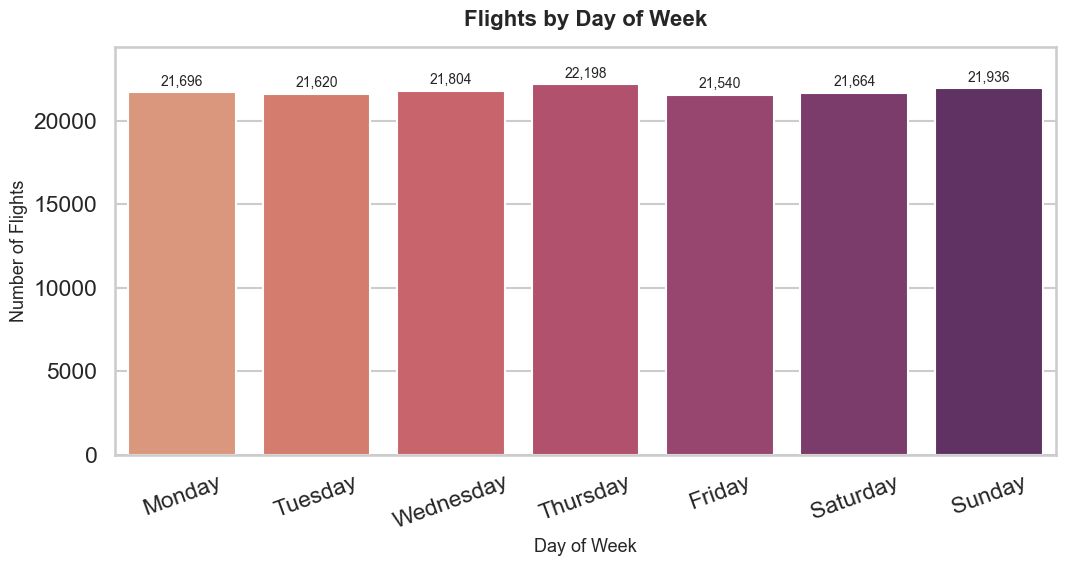

Flights by Day of Week:
day_of_week
Monday       21696
Tuesday      21620
Wednesday    21804
Thursday     22198
Friday       21540
Saturday     21664
Sunday       21936
Name: count, dtype: int64

Busiest day: Thursday (22,198 flights)
Least busy day: Friday (21,540 flights)


In [17]:
# Define the correct order of weekdays
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

# Count flights by day of week in the correct order
flights_by_day = df["day_of_week"].value_counts().reindex(day_order)

# Create the plot
plt.figure(figsize=(11, 6))
ax = sns.barplot(
    x=flights_by_day.index,
    y=flights_by_day.values,
    palette="flare"
)

# Add value labels above bars
for i, value in enumerate(flights_by_day.values):
    ax.text(
        i,
        value + (flights_by_day.max() * 0.01),
        f"{value:,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Add headroom above the tallest bar
ax.set_ylim(0, flights_by_day.max() * 1.10)

plt.title("Flights by Day of Week", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Day of Week", fontsize=13)
plt.ylabel("Number of Flights", fontsize=13)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Identify the busiest and least busy day
busiest_day = flights_by_day.idxmax()
busiest_day_count = flights_by_day.max()

least_busy_day = flights_by_day.idxmin()
least_busy_day_count = flights_by_day.min()

print("Flights by Day of Week:")
print(flights_by_day)

print(f"\nBusiest day: {busiest_day} ({busiest_day_count:,} flights)")
print(f"Least busy day: {least_busy_day} ({least_busy_day_count:,} flights)")

> **Insight:** Flight volumes are relatively stable across the week, with a slight increase toward the weekend.
>
> **Business Value:** Airlines can fine-tune schedules by adding capacity during peak weekend periods to capture higher travel demand more efficiently.

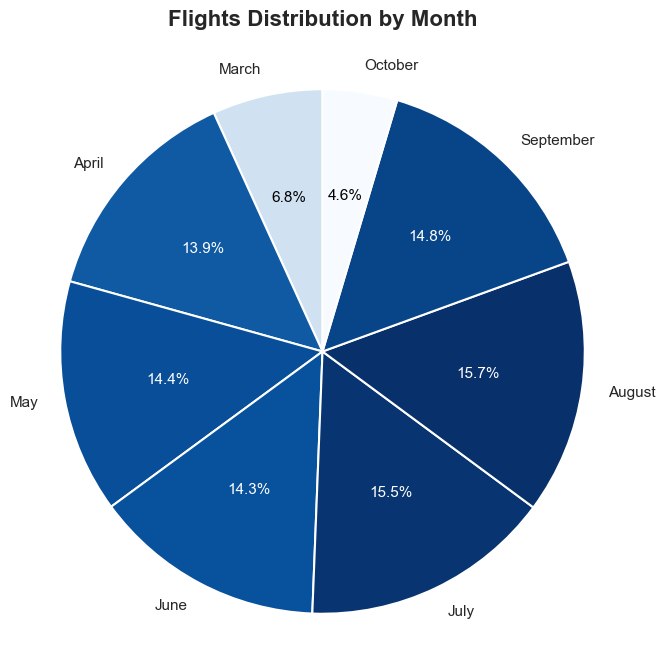

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define the correct chronological order of months
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

# Count flights by month in chronological order
flights_by_month = df["month_name"].value_counts().reindex(month_order).dropna()

# Normalize values to create color intensity
norm = (flights_by_month - flights_by_month.min()) / (flights_by_month.max() - flights_by_month.min())

# Generate colors
colors = plt.cm.Blues(norm)

# Create the plot
plt.figure(figsize=(7,7))

wedges, texts, autotexts = plt.pie(
    flights_by_month.values,
    labels=flights_by_month.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    textprops={"fontsize": 11}
)

# Adjust text color based on slice darkness
for i, autotext in enumerate(autotexts):
    if norm.iloc[i] > 0.5:
        autotext.set_color("white")
    else:
        autotext.set_color("black")

# Add title
plt.title("Flights Distribution by Month", fontsize=16, fontweight="bold", pad=15)

plt.axis("equal")
plt.tight_layout()
plt.show()

> **Insight:**  
> Flight activity shows moderate seasonal variation throughout the year. The distribution indicates slightly higher flight volumes during the summer months, particularly in July and August, while early months such as March and October show comparatively lower traffic levels.
>
> **Business Value:**  
> Recognizing seasonal patterns in flight demand enables airport authorities to plan capacity more effectively. During peak travel months, additional operational resources such as staffing, gate allocation, and passenger services can be deployed to accommodate increased traffic and maintain smooth airport operations.

### Number of Flights by Month
**Why this chart matters:** To identify seasonality and determine which months experience higher traffic.

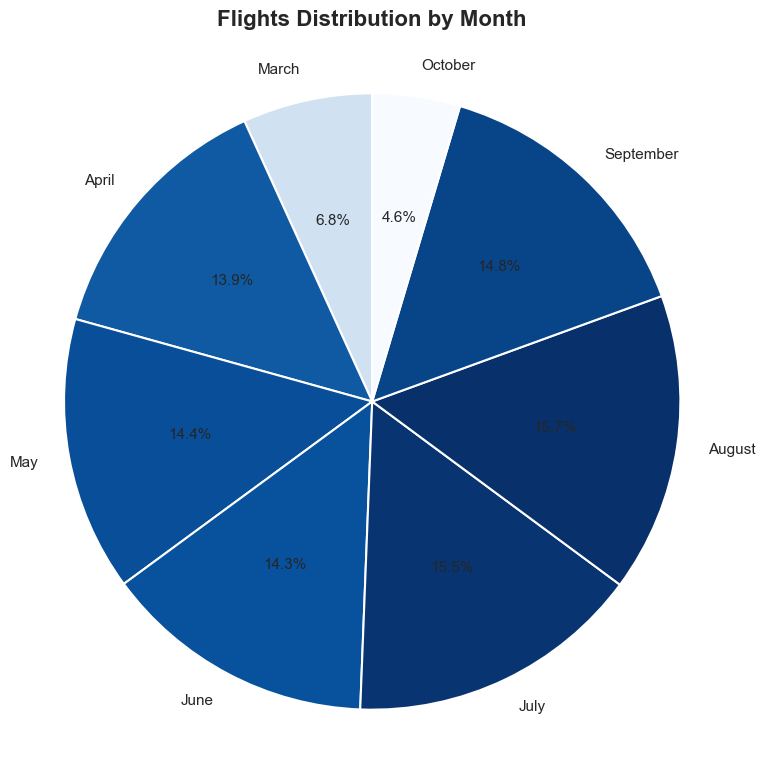

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define the correct chronological order of months
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

# Count flights by month in chronological order
flights_by_month = df["month_name"].value_counts().reindex(month_order).dropna()

# Normalize values to create color intensity
norm = (flights_by_month - flights_by_month.min()) / (flights_by_month.max() - flights_by_month.min())

# Generate colors based on value intensity
colors = plt.cm.Blues(norm)

# Create the plot
plt.figure(figsize=(8,8))

plt.pie(
    flights_by_month.values,
    labels=flights_by_month.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    textprops={"fontsize": 11}
)

# Add title
plt.title("Flights Distribution by Month", fontsize=16, fontweight="bold", pad=15)

# Ensure pie chart is circular
plt.axis("equal")

plt.tight_layout()
plt.show()

> **Insight:** Flight activity rises clearly during the summer months, showing a strong seasonal demand pattern.
>
> **Business Value:** Airlines and airport planners can scale operations during peak travel months to maximize capacity utilization and revenue.

---
## 4. Forecasting Analysis
After understanding historical flight patterns, this section shifts from descriptive analytics to predictive analytics by forecasting future flight volume using multiple time-series approaches.


In [19]:
# =========================
# Forecasting Preparation
# =========================

# Aggregate the number of flights per day
daily_flights = df.groupby("date").size().reset_index(name="flights")

# Ensure the date column is in datetime format
daily_flights["date"] = pd.to_datetime(daily_flights["date"])

# Sort the data chronologically
daily_flights = daily_flights.sort_values("date").reset_index(drop=True)

# Display the first rows
daily_flights.head()

,date,flights
0,2025-03-15 00:00:00+03:00,603
1,2025-03-16 00:00:00+03:00,593
2,2025-03-17 00:00:00+03:00,558
3,2025-03-18 00:00:00+03:00,432
4,2025-03-19 00:00:00+03:00,593


### Daily Flight Volume Over Time
**Why this chart matters:** To prepare the time series for forecasting and examine how flight activity evolves over time.

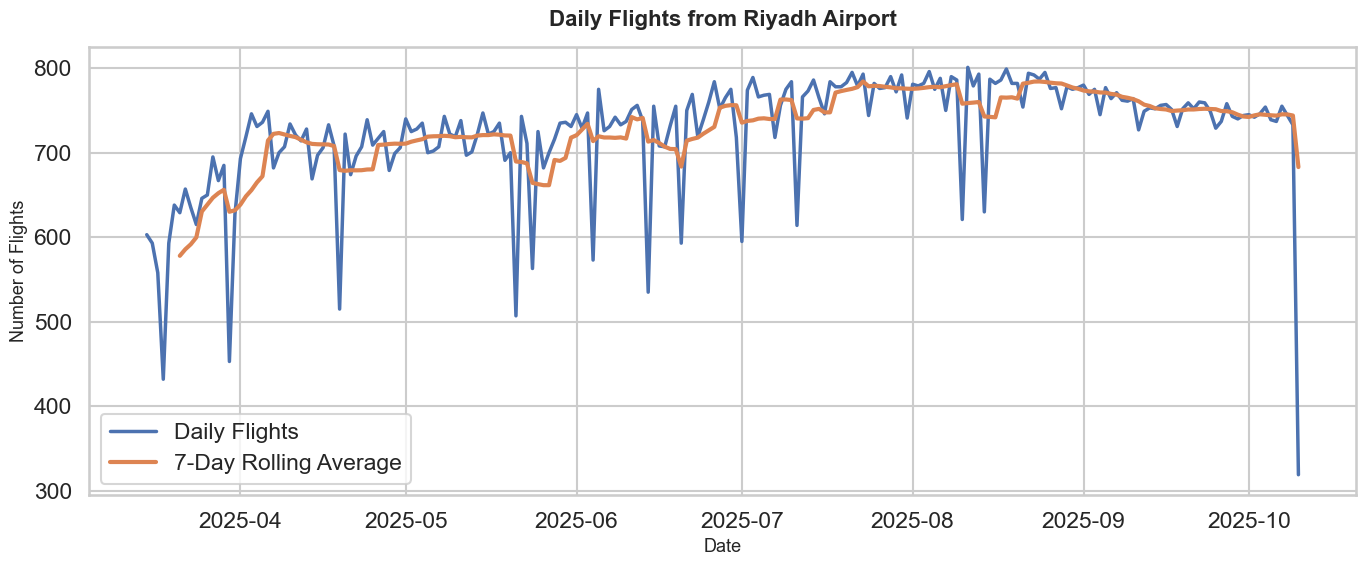

In [20]:
# Plot daily flight counts to inspect the historical trend
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=daily_flights,
    x="date",
    y="flights",
    linewidth=2.5,
    label="Daily Flights"
)

# Add a 7-day rolling average for smoother trend visualization
daily_flights["rolling_7"] = daily_flights["flights"].rolling(window=7).mean()

sns.lineplot(
    data=daily_flights,
    x="date",
    y="rolling_7",
    linewidth=3,
    label="7-Day Rolling Average"
)

plt.title("Daily Flights from Riyadh Airport", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Date", fontsize=13)
plt.ylabel("Number of Flights", fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

> **Interpretation:**  
> The figure illustrates the daily number of flights departing from Riyadh Airport during the observed period.  
> While the raw daily values fluctuate significantly from day to day, the 7-day rolling average smooths these variations and highlights the underlying movement in flight activity over time.
>
> **What this means:**  
> The smoothed trend shows a gradual increase in flight volumes during the early and middle parts of the timeline, followed by a relatively stable level of activity toward the later months.  
> The sharp drops visible in some days likely represent irregular operational variations or incomplete daily records rather than long-term structural changes in airport traffic.

In [21]:
# Create a time-based train/test split (80% train, 20% test)
split_index = int(len(daily_flights) * 0.8)

train = daily_flights.iloc[:split_index].copy()
test = daily_flights.iloc[split_index:].copy()

print("Training period:")
print(train["date"].min(), "to", train["date"].max())

print("\nTesting period:")
print(test["date"].min(), "to", test["date"].max())

print("\nTrain shape:", train.shape)
print("Test shape:", test.shape)

Training period:
2025-03-15 00:00:00+03:00 to 2025-08-29 00:00:00+03:00

Testing period:
2025-08-30 00:00:00+03:00 to 2025-10-10 00:00:00+03:00

Train shape: (168, 3)
Test shape: (42, 3)


### Train/Test Split for Forecasting
**Why this chart matters:** To verify that the forecasting models are evaluated using a proper chronological split.

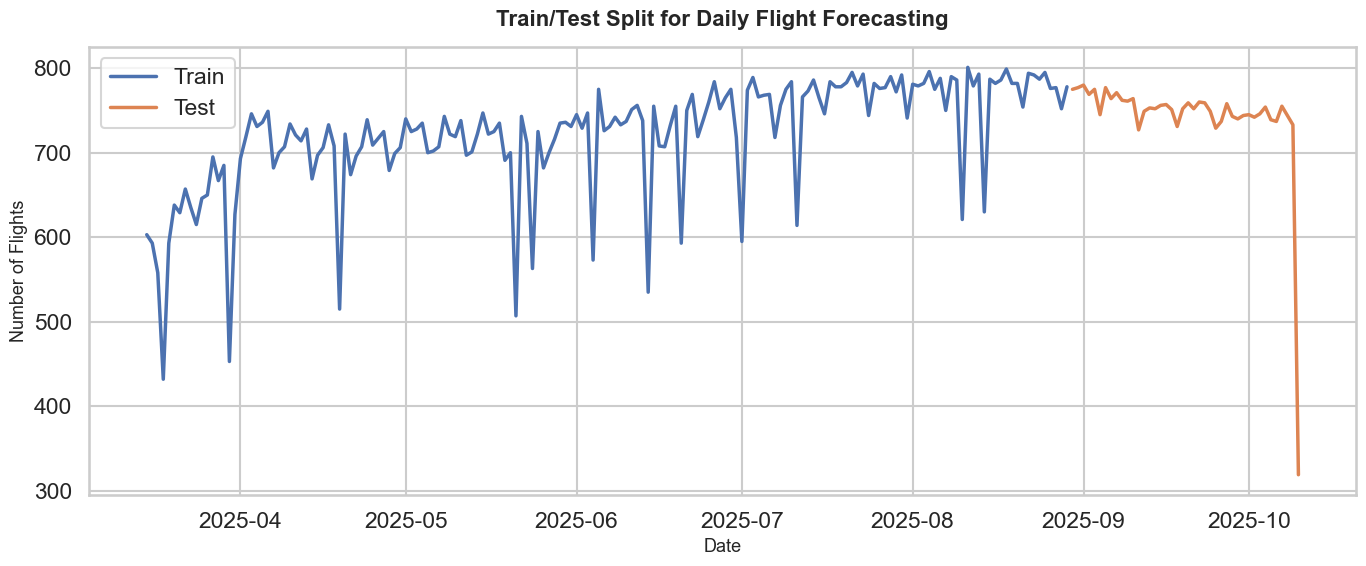

In [22]:
# Plot the train/test split to verify chronological separation
plt.figure(figsize=(14, 6))

plt.plot(train["date"], train["flights"], label="Train", linewidth=2.5)
plt.plot(test["date"], test["flights"], label="Test", linewidth=2.5)

plt.title("Train/Test Split for Daily Flight Forecasting", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Date", fontsize=13)
plt.ylabel("Number of Flights", fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

> **Interpretation:**  
> The figure shows how the dataset was divided into training and testing periods for the forecasting task.  
> The training segment contains the earlier historical observations used to fit the forecasting models, while the testing segment represents the most recent portion of the data reserved for evaluation.
>
> **What this means:**  
> The training period reveals a gradual increase in daily flight activity over time, with noticeable short-term fluctuations.  
> In contrast, the testing period appears relatively stable around a consistent flight level, which provides a realistic scenario for evaluating how well forecasting models can reproduce recent patterns.  
> The sharp drop in the final observation likely reflects an incomplete daily record rather than a true operational decline.

In [23]:
from sklearn.linear_model import LinearRegression

# Create numeric time index for regression
train_lr = train.copy()
test_lr = test.copy()

train_lr["time_index"] = range(len(train_lr))
test_lr["time_index"] = range(len(train_lr), len(train_lr) + len(test_lr))

# Train the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(train_lr[["time_index"]], train_lr["flights"])

# Generate predictions
test["lr_pred"] = lr_model.predict(test_lr[["time_index"]])

# Display sample predictions
test[["date", "flights", "lr_pred"]].head()

,date,flights,lr_pred
168,2025-08-30 00:00:00+03:00,775,792.901411
169,2025-08-31 00:00:00+03:00,777,793.742595
170,2025-09-01 00:00:00+03:00,780,794.583778
171,2025-09-02 00:00:00+03:00,769,795.424961
172,2025-09-03 00:00:00+03:00,775,796.266144


In [24]:
from statsmodels.tsa.arima.model import ARIMA
import warnings

# Suppress common ARIMA warnings for cleaner output
warnings.filterwarnings("ignore")

# Train ARIMA model
arima_model = ARIMA(train["flights"], order=(5, 1, 2))
arima_fitted = arima_model.fit()

# Forecast over the test period
test["arima_pred"] = arima_fitted.forecast(steps=len(test))

# Display sample predictions
test[["date", "flights", "arima_pred"]].head()

,date,flights,arima_pred
168,2025-08-30 00:00:00+03:00,775,776.723020
169,2025-08-31 00:00:00+03:00,777,776.549677
170,2025-09-01 00:00:00+03:00,780,776.483310
171,2025-09-02 00:00:00+03:00,769,777.684950
172,2025-09-03 00:00:00+03:00,775,775.977867


In [25]:
from prophet import Prophet
import pandas as pd

# Prepare Prophet training data
prophet_train = train[["date", "flights"]].rename(
    columns={"date": "ds", "flights": "y"}
).copy()

# Remove timezone from ds
prophet_train["ds"] = pd.to_datetime(prophet_train["ds"]).dt.tz_localize(None)

# Initialize and train Prophet model
prophet_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False
)

prophet_model.fit(prophet_train)

# Create a dataframe for the test period
future_test = test[["date"]].rename(columns={"date": "ds"}).copy()

# Remove timezone from test dates too
future_test["ds"] = pd.to_datetime(future_test["ds"]).dt.tz_localize(None)

# Forecast on the test period
prophet_forecast_test = prophet_model.predict(future_test)

# Store predictions
test = test.copy()
test["prophet_pred"] = prophet_forecast_test["yhat"].values

# Display sample predictions
test[["date", "flights", "prophet_pred"]].head()

15:13:15 - cmdstanpy - INFO - Chain [1] start processing
15:13:15 - cmdstanpy - INFO - Chain [1] done processing


,date,flights,prophet_pred
168,2025-08-30 00:00:00+03:00,775,783.493455
169,2025-08-31 00:00:00+03:00,777,795.888745
170,2025-09-01 00:00:00+03:00,780,785.827472
171,2025-09-02 00:00:00+03:00,769,782.190264
172,2025-09-03 00:00:00+03:00,775,790.446164


### Actual vs Predicted Comparison
**Why this chart matters:** To compare how closely each forecasting model follows the real flight volumes in the test period.

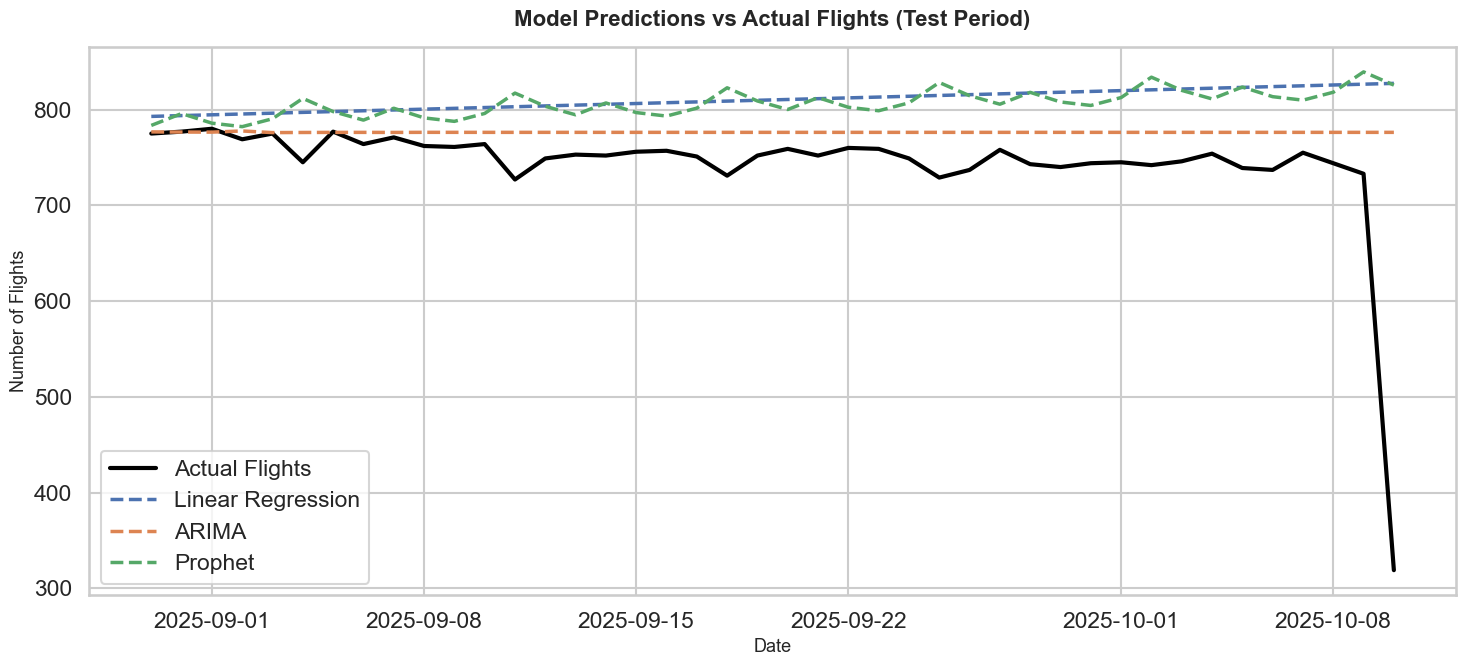

In [26]:
# Compare actual values with predictions from all three models
plt.figure(figsize=(15, 7))

plt.plot(test["date"], test["flights"], label="Actual Flights", linewidth=3, color="black")
plt.plot(test["date"], test["lr_pred"], label="Linear Regression", linewidth=2.5, linestyle="--")
plt.plot(test["date"], test["arima_pred"], label="ARIMA", linewidth=2.5, linestyle="--")
plt.plot(test["date"], test["prophet_pred"], label="Prophet", linewidth=2.5, linestyle="--")

plt.title("Model Predictions vs Actual Flights (Test Period)", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Date", fontsize=13)
plt.ylabel("Number of Flights", fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

> **Interpretation:**  
> The figure compares the actual flight counts in the test period with the predictions generated by the forecasting models.  
> Linear Regression captures the general upward trend but does not follow the daily fluctuations closely.  
> ARIMA produces relatively stable predictions that remain close to the overall average level of the series.  
> Prophet attempts to capture short-term variability and follows some of the movements in the data, although it still deviates from the exact daily values.

> **Important observation:**  
> The sharp drop in the final observation is likely caused by **an incomplete or partially recorded day** in the dataset rather than a real operational decrease in flights. Such anomalies can affect the visual comparison and should be considered when interpreting forecasting performance.

> **What this means:**  
> Overall, the forecasting models capture the **general level and trend of flight activity**, but they struggle to reproduce the **day-to-day variability** present in the operational data.

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Define a helper function for evaluation
def evaluate_forecast(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return pd.DataFrame({
        "Model": [model_name],
        "MAE": [mae],
        "RMSE": [rmse],
        "MAPE (%)": [mape]
    })

# Evaluate all models
lr_results = evaluate_forecast(test["flights"], test["lr_pred"], "Linear Regression")
arima_results = evaluate_forecast(test["flights"], test["arima_pred"], "ARIMA")
prophet_results = evaluate_forecast(test["flights"], test["prophet_pred"], "Prophet")

# Combine results
results_df = pd.concat([lr_results, arima_results, prophet_results], ignore_index=True)
results_df = results_df.sort_values("RMSE").reset_index(drop=True)

results_df

,Model,MAE,RMSE,MAPE (%)
0,ARIMA,33.848704,75.409190,6.493840
1,Prophet,63.670144,97.390198,10.694755
2,Linear Regression,67.479001,98.751922,11.198273


### RMSE Comparison Across Models
**Why this chart matters:** To compare models based on error magnitude, with greater emphasis on larger forecast errors.

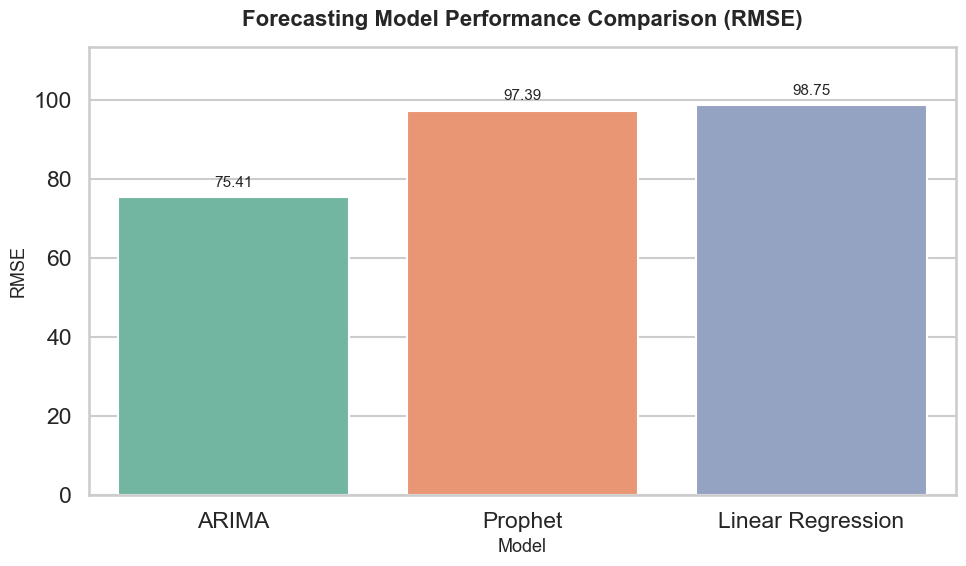

In [28]:
# Visualize RMSE comparison across models
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=results_df, x="Model", y="RMSE", palette="Set2")

# Add value labels above bars
for i, value in enumerate(results_df["RMSE"]):
    ax.text(
        i,
        value + (results_df["RMSE"].max() * 0.02),
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=11
    )

# Add headroom
ax.set_ylim(0, results_df["RMSE"].max() * 1.15)

plt.title("Forecasting Model Performance Comparison (RMSE)", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Model", fontsize=13)
plt.ylabel("RMSE", fontsize=13)
plt.tight_layout()
plt.show()

> **Interpretation:**  
> The bar chart compares the forecasting accuracy of the three models using Root Mean Squared Error (RMSE).  
> Lower RMSE values indicate better predictive performance because they represent smaller differences between predicted and actual flight volumes.
>
> **What this means:**  
> Among the evaluated models, **ARIMA achieved the lowest RMSE**, indicating that it produced the most accurate forecasts during the test period.  
> Both **Prophet and Linear Regression** show higher error values, suggesting that they were less effective in capturing the temporal dynamics of the flight activity in this dataset.
> Based on this comparison, ARIMA appears to be the most suitable forecasting model for this time series.

### MAE Comparison Across Models
**Why this chart matters:** To compare models based on average absolute forecasting error in an easy-to-interpret way.

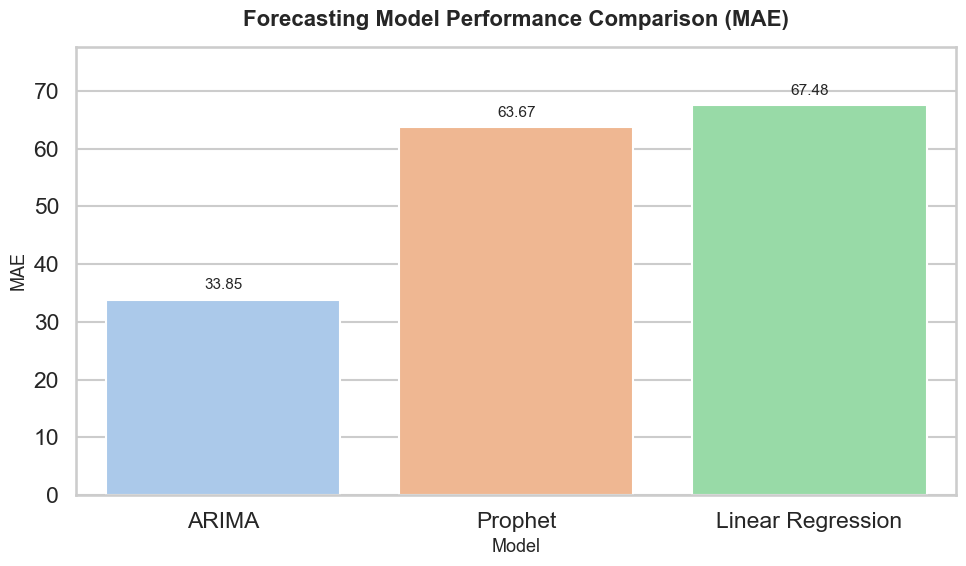

In [29]:
# Visualize MAE comparison across models
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=results_df, x="Model", y="MAE", palette="pastel")

# Add value labels above bars
for i, value in enumerate(results_df["MAE"]):
    ax.text(
        i,
        value + (results_df["MAE"].max() * 0.02),
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=11
    )

# Add headroom
ax.set_ylim(0, results_df["MAE"].max() * 1.15)

plt.title("Forecasting Model Performance Comparison (MAE)", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Model", fontsize=13)
plt.ylabel("MAE", fontsize=13)
plt.tight_layout()
plt.show()

> **Interpretation:**  
> This chart compares the forecasting performance of the models using Mean Absolute Error (MAE), which measures the average magnitude of prediction errors without considering their direction.  
> Lower MAE values indicate that the predicted flight volumes are closer to the actual observed values.
>
> **What this means:**  
> The ARIMA model achieved the lowest MAE, indicating that its predictions were, on average, closer to the real flight volumes than the other models.  
> Prophet and Linear Regression show higher error values, suggesting that they were less accurate in capturing the daily flight patterns in this dataset.
> The consistency between the RMSE and MAE results further supports ARIMA as the most reliable forecasting model for this time series.

In [30]:
# Identify the best model based on the lowest RMSE
best_model_name = results_df.loc[0, "Model"]

print("Best model based on RMSE:", best_model_name)

Best model based on RMSE: ARIMA


In [31]:
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
import pandas as pd
import numpy as np

# Forecast the next 14 days
future_days = 14
last_date = pd.to_datetime(daily_flights["date"], utc=True).dt.tz_convert(None).max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=future_days)

# Linear Regression future forecast
full_data_lr = daily_flights.copy()
full_data_lr["time_index"] = range(len(full_data_lr))

future_time_index = np.arange(len(full_data_lr), len(full_data_lr) + future_days).reshape(-1, 1)

lr_full_model = LinearRegression()
lr_full_model.fit(full_data_lr[["time_index"]], full_data_lr["flights"])
lr_future_pred = lr_full_model.predict(future_time_index)

# ARIMA future forecast
arima_full_model = ARIMA(daily_flights["flights"], order=(5, 1, 2))
arima_full_fitted = arima_full_model.fit()
arima_future_pred = arima_full_fitted.forecast(steps=future_days)

# Prophet future forecast
prophet_full_data = daily_flights[["date", "flights"]].rename(
    columns={"date": "ds", "flights": "y"}
).copy()

prophet_full_data["ds"] = pd.to_datetime(prophet_full_data["ds"], utc=True).dt.tz_convert(None)

prophet_full_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False
)

prophet_full_model.fit(prophet_full_data)

future_prophet = prophet_full_model.make_future_dataframe(periods=future_days)
prophet_future_forecast = prophet_full_model.predict(future_prophet)
prophet_future_pred = prophet_future_forecast.tail(future_days)["yhat"].values

# Combine future forecasts
future_forecast_df = pd.DataFrame({
    "date": future_dates,
    "Linear Regression": lr_future_pred,
    "ARIMA": arima_future_pred.values,
    "Prophet": prophet_future_pred
})

future_forecast_df

15:13:16 - cmdstanpy - INFO - Chain [1] start processing
15:13:16 - cmdstanpy - INFO - Chain [1] done processing


,date,Linear Regression,ARIMA,Prophet
0,2025-10-10 21:00:00,779.652814,681.448303,732.253090
1,2025-10-11 21:00:00,780.161462,686.333320,740.370612
2,2025-10-12 21:00:00,780.670109,671.477402,731.358273
3,2025-10-13 21:00:00,781.178757,666.190926,727.838172
4,2025-10-14 21:00:00,781.687405,687.102361,733.024974
5,2025-10-15 21:00:00,782.196053,666.112153,745.245608
6,2025-10-16 21:00:00,782.704700,664.812103,722.239236
7,2025-10-17 21:00:00,783.213348,666.778180,728.028881
8,2025-10-18 21:00:00,783.721996,667.541928,736.146403
9,2025-10-19 21:00:00,784.230644,666.451920,727.134064


### Next 14-Day Forecast
**Why this chart matters:** To estimate short-term future flight demand and support capacity planning.

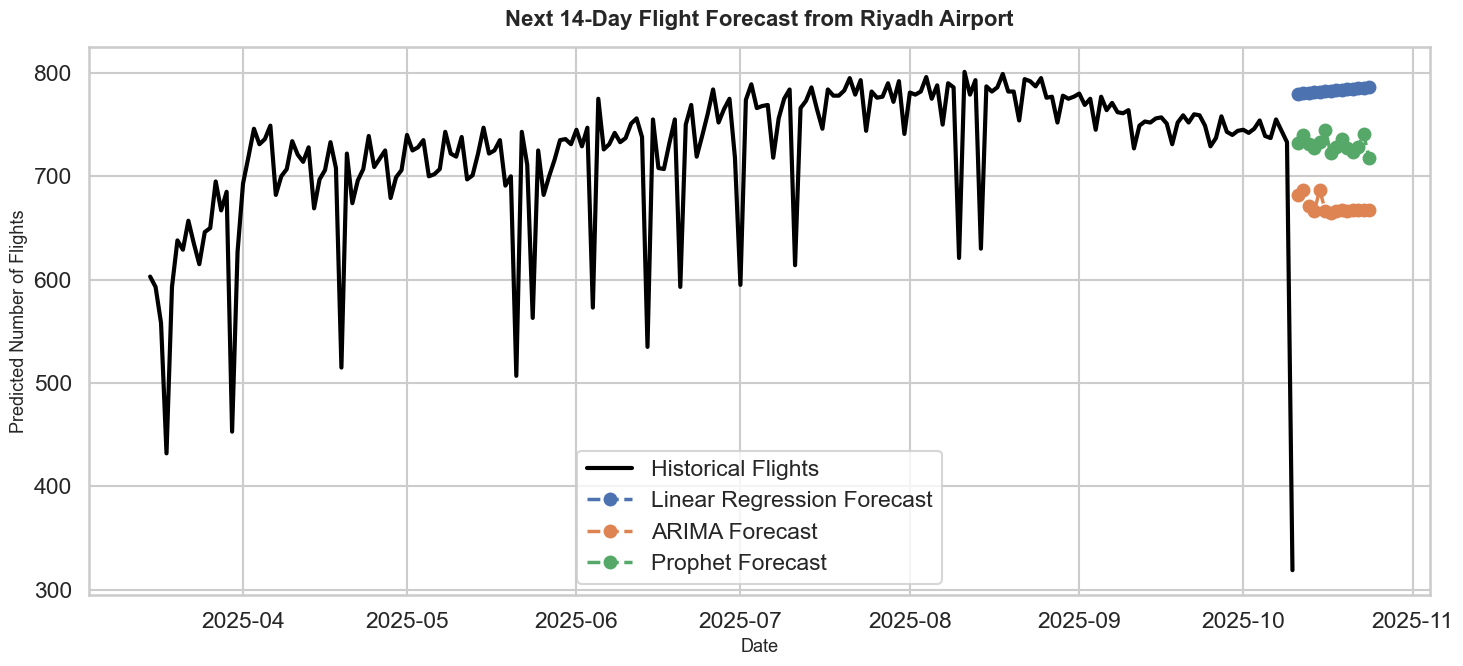

In [32]:
# Plot historical data and future forecasts from all models
plt.figure(figsize=(15, 7))

# Historical data
plt.plot(
    daily_flights["date"],
    daily_flights["flights"],
    label="Historical Flights",
    linewidth=3,
    color="black"
)

# Future forecasts
plt.plot(
    future_forecast_df["date"],
    future_forecast_df["Linear Regression"],
    label="Linear Regression Forecast",
    linewidth=2.5,
    linestyle="--",
    marker="o"
)

plt.plot(
    future_forecast_df["date"],
    future_forecast_df["ARIMA"],
    label="ARIMA Forecast",
    linewidth=2.5,
    linestyle="--",
    marker="o"
)

plt.plot(
    future_forecast_df["date"],
    future_forecast_df["Prophet"],
    label="Prophet Forecast",
    linewidth=2.5,
    linestyle="--",
    marker="o"
)

plt.title("Next 14-Day Flight Forecast from Riyadh Airport", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Date", fontsize=13)
plt.ylabel("Predicted Number of Flights", fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

> **Interpretation:**  
> The figure presents the predicted number of daily flights for the next 14 days generated by the forecasting models.  
> Each model extends the historical flight pattern differently, producing slightly different estimates for the upcoming period.
>
> **What this means:**  
> Linear Regression projects a gradual upward continuation of the historical trend, while the ARIMA forecast remains closer to the recent average level of flight activity.  
> Prophet produces moderate fluctuations, reflecting its attempt to capture short-term variability observed in the historical data.

In [33]:
# Round forecast results for a cleaner presentation
future_forecast_rounded = future_forecast_df.copy()
future_forecast_rounded["Linear Regression"] = future_forecast_rounded["Linear Regression"].round(0).astype(int)
future_forecast_rounded["ARIMA"] = future_forecast_rounded["ARIMA"].round(0).astype(int)
future_forecast_rounded["Prophet"] = future_forecast_rounded["Prophet"].round(0).astype(int)

future_forecast_rounded

,date,Linear Regression,ARIMA,Prophet
0,2025-10-10 21:00:00,780,681,732
1,2025-10-11 21:00:00,780,686,740
2,2025-10-12 21:00:00,781,671,731
3,2025-10-13 21:00:00,781,666,728
4,2025-10-14 21:00:00,782,687,733
5,2025-10-15 21:00:00,782,666,745
6,2025-10-16 21:00:00,783,665,722
7,2025-10-17 21:00:00,783,667,728
8,2025-10-18 21:00:00,784,668,736
9,2025-10-19 21:00:00,784,666,727


### Actual vs Predicted Flights Comparison

**Why this chart matters:**  
This visualization evaluates how well each forecasting model reproduces the actual observed flight activity during the testing period.  

By comparing the predicted values with the real flight counts, we can visually assess the prediction accuracy and identify which model produces estimates that are closest to the actual operational data.

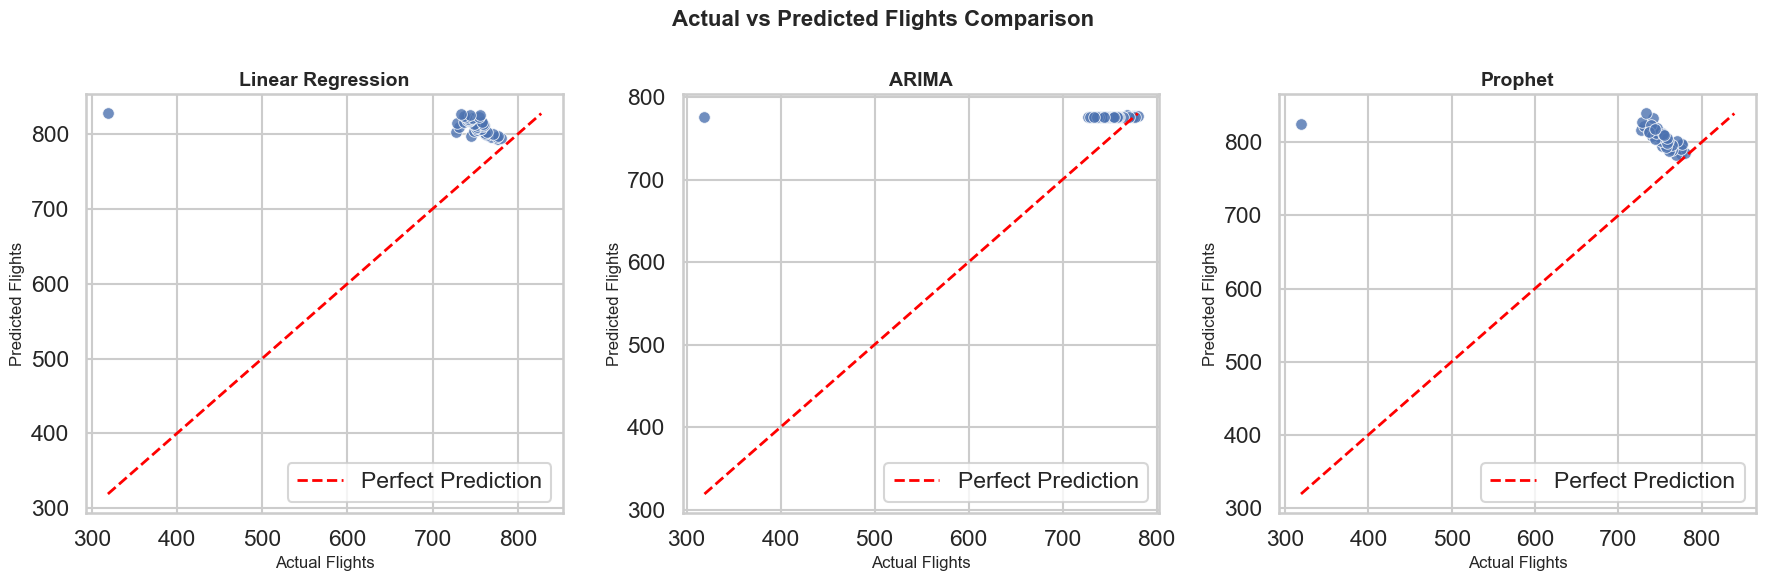

In [34]:
# =========================
# Actual vs Predicted Scatter Plots
# =========================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models = [
    ("Linear Regression", "lr_pred"),
    ("ARIMA", "arima_pred"),
    ("Prophet", "prophet_pred")
]

for ax, (model_name, col) in zip(axes, models):

    sns.scatterplot(
        x=test["flights"],
        y=test[col],
        ax=ax,
        s=70,
        alpha=0.8
    )

    # Perfect prediction line (45°)
    min_val = min(test["flights"].min(), test[col].min())
    max_val = max(test["flights"].max(), test[col].max())

    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        color="red",
        linestyle="--",
        linewidth=2,
        label="Perfect Prediction"
    )

    ax.set_title(f"{model_name}", fontsize=14, fontweight="bold")
    ax.set_xlabel("Actual Flights", fontsize=12)
    ax.set_ylabel("Predicted Flights", fontsize=12)

    ax.legend()

plt.suptitle(
    "Actual vs Predicted Flights Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

> **Interpretation:**  
> The scatter plots compare actual flight counts with the predicted values produced by each forecasting model.  
> The dashed red diagonal line represents the **perfect prediction line**, where predicted values would exactly match the real observations.
>
> **Model Behavior:**  
> Points that lie closer to this line indicate more accurate predictions.  
> The ARIMA model shows predictions that align more closely with the perfect prediction line, indicating stronger predictive performance.  
> In contrast, Linear Regression and Prophet exhibit slightly larger deviations, suggesting higher forecasting error.
>
> **Conclusion:**  
> Based on both the visual comparison and the evaluation metrics presented earlier, **ARIMA provides the most reliable short-term forecast for the Riyadh Airport flight dataset**.

---
## 5. Reflection and Limitations

While this analysis provided useful insights into Riyadh Airport flight activity, several limitations should be considered.

First, the dataset covers only about **seven months of observations**, which means it does not represent a full yearly cycle. Because of this, long-term seasonal patterns could not be fully captured.

Second, flight activity can be influenced by many external operational factors such as scheduling changes, airline decisions, or airport operational adjustments. These factors introduce variability that forecasting models may not fully capture.

Third, the forecasting models were trained using limited historical information and basic temporal features. While the models were able to capture the **overall level of flight activity**, they were less successful at reproducing the **day-to-day fluctuations** observed in the real data.

Future work could improve the analysis by including **longer historical datasets**, additional operational variables, and more advanced forecasting techniques to better model short-term variability.

---

## 6. Conclusion

This notebook analyzed flight departure activity from **King Khalid International Airport in Riyadh** using a recent operational dataset updated to **October 2025**.  
The analysis combined exploratory data analysis and time-series forecasting to better understand airport traffic patterns and evaluate short-term flight demand.

## Questions Addressed

The analysis aimed to answer several important questions:

- How does daily flight activity change over time?
- Which destinations receive the most flights from Riyadh?
- Which airlines operate the largest share of departures?
- How are flights distributed between domestic and international routes?
- How are airport terminals utilized?
- Can short-term flight activity be predicted using forecasting models?

## Key Insights from the Exploratory Analysis

The exploratory analysis revealed several important patterns:

- **Stable flight activity:**  
  Daily flight counts fluctuate but generally remain within a relatively consistent range, indicating stable airport operations.

- **Regional connectivity dominance:**  
  Many international routes connect Riyadh with nearby regional hubs such as **Dubai, Cairo, and Istanbul**, highlighting the importance of regional travel demand.

- **Airline activity concentration:**  
  A small number of airlines account for a large share of flights, which is typical for major hub airports.

- **Terminal utilization imbalance:**  
  The analysis showed that **Terminal 5 handled the largest share of flights**, since it was primarily dedicated to domestic routes.  
  This created higher operational pressure on that terminal compared with others.

  Notably, a major operational change occurred on **February 25, 2026**, when domestic flights were redistributed to **Terminals 3 and 4** at Riyadh Airport.  
  This real-world adjustment highlights how analyzing airport operational data can support **data-driven decisions** that improve passenger flow and reduce congestion.

## Forecasting Results

To estimate short-term flight demand, three forecasting approaches were evaluated:

- Linear Regression  
- ARIMA  
- Prophet  

Model performance was compared using **RMSE and MAE** metrics.

The results showed that **ARIMA achieved the lowest forecasting error**, indicating the most accurate predictions for this dataset.  
Linear Regression captured the overall trend but struggled with short-term fluctuations, while Prophet attempted to model variability but produced higher errors.

The **14-day forecast** suggests that flight activity will likely remain **relatively stable in the short term**, with moderate fluctuations around the recent operational level.

## Final Remarks

Overall, this analysis demonstrates how combining **data preprocessing, exploratory data analysis, and forecasting techniques** can provide meaningful insights into airport operations.  
Such analyses help reveal traffic patterns, evaluate operational conditions, and support better planning and decision-making in aviation environments.